# BRFSS 2023 — Exploración de Datos

**Behavioral Risk Factor Surveillance System** — CDC, Estados Unidos  
432,733 encuestados sobre enfermedades crónicas, hábitos y salud general.

Este dataset fue la base para entrenar el modelo de alertas de salud de CareBridge.

| Archivo | Qué contiene |
|---|---|
| `brfss_clean.csv` | Variables en español, legibles |
| `brfss_features.csv` | Variables codificadas para ML |

## 0. Imports y carga

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import numpy as np
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

print("Librerías cargadas correctamente")

Librerías cargadas correctamente


In [26]:
df   = pd.read_csv('../processed/brfss_clean.csv')
df_f = pd.read_csv('../processed/brfss_features.csv')

print(f"brfss_clean    → {len(df):,} filas  |  {df.shape[1]} columnas")

brfss_clean    → 387,566 filas  |  29 columnas


## 1. Primer vistazo al dataset

In [3]:
df.head(5)

,salud_general,ejercicio_ultimo_mes,consumo_alcohol,categoria_imc,grupo_edad,sexo,altura_cm,tiene_diabetes,tiene_cardiopatia_coronaria,tiene_depresion,...,categoria_imc_enc,grupo_edad_enc,sexo_enc,tiene_diabetes_enc,tiene_cardiopatia_coronaria_enc,tiene_depresion_enc,tiene_cancer_piel_enc,tiene_otro_cancer_enc,tiene_artritis_enc,tiene_asma_enc
0,muy_buena,no,no,obeso,65+,femenino,160.0,si,no,no,...,2,5,0,2,0,0,0,0,0,0
1,muy_buena,si,no,sobrepeso,65+,femenino,145.0,pre_diabetes,no,si,...,3,5,0,1,0,1,0,0,1,0
2,regular,si,no,normal,65+,femenino,163.0,pre_diabetes,no,no,...,1,5,0,1,0,0,0,0,1,1
3,muy_buena,si,no,sobrepeso,65+,femenino,168.0,pre_diabetes,no,si,...,3,5,0,1,0,1,1,1,1,0
4,regular,si,si,sobrepeso,65+,femenino,173.0,si,no,si,...,3,5,0,2,0,1,0,1,1,0


In [4]:
df_f.head(5)

,poor_mental_health_days,poor_physical_health_days,weight_kg,height_cm,bmi_computed,has_diabetes_bin,has_high_bp_bin,has_heart_disease_bin,has_depression_bin,has_asthma_bin,...,physical_activity_category_enc,education_level_enc,income_level_enc,has_diabetes_enc,has_high_bp_enc,has_heart_disease_enc,has_depression_enc,has_asthma_enc,has_high_cholesterol_enc,has_stroke_enc
0,88.0,88.0,78.02,160.0,30.5,1.0,1.0,0.0,0.0,0.0,...,2,3,6,1,1,0,0,0,0,0
1,88.0,88.0,59.87,145.0,28.5,0.0,1.0,0.0,1.0,0.0,...,1,3,6,2,1,0,1,0,1,0
2,2.0,6.0,58.97,163.0,22.2,0.0,1.0,0.0,0.0,1.0,...,4,0,5,2,1,0,0,1,1,0
3,88.0,2.0,77.11,168.0,27.3,0.0,0.0,0.0,1.0,0.0,...,4,3,6,2,2,0,1,0,0,0
4,88.0,88.0,77.11,173.0,25.8,1.0,1.0,0.0,1.0,0.0,...,1,3,4,1,1,0,1,0,0,0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 387566 entries, 0 to 387565
Data columns (total 29 columns):
 #   Column                           Non-Null Count   Dtype  
---  ------                           --------------   -----  
 0   salud_general                    387566 non-null  object 
 1   ejercicio_ultimo_mes             387566 non-null  object 
 2   consumo_alcohol                  387566 non-null  object 
 3   categoria_imc                    387566 non-null  object 
 4   grupo_edad                       387566 non-null  object 
 5   sexo                             387566 non-null  object 
 6   altura_cm                        387566 non-null  float64
 7   tiene_diabetes                   387566 non-null  object 
 8   tiene_cardiopatia_coronaria      387566 non-null  object 
 9   tiene_depresion                  387566 non-null  object 
 10  tiene_cancer_piel                387566 non-null  object 
 11  tiene_otro_cancer                387566 non-null  object 
 12  ti

In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
altura_cm,387566.0,170.120276,10.636691,100.00,163.00,170.00,178.00,241.0
peso_kg,387566.0,83.099108,21.122609,22.68,68.04,80.74,92.99,284.0
riesgo_salud,387566.0,0.766706,0.774770,0.00,0.00,1.00,1.00,2.0
ejercicio_ultimo_mes_enc,387566.0,0.735978,0.440812,0.00,0.00,1.00,1.00,1.0
consumo_alcohol_enc,387566.0,0.547868,0.497704,0.00,0.00,1.00,1.00,1.0
categoria_imc_enc,387566.0,2.013696,0.808339,0.00,1.00,2.00,3.00,3.0
grupo_edad_enc,387566.0,3.403763,1.629337,0.00,2.00,4.00,5.00,5.0
sexo_enc,387566.0,0.464494,0.498738,0.00,0.00,0.00,1.00,1.0
tiene_diabetes_enc,387566.0,1.195752,0.477696,0.00,1.00,1.00,1.00,3.0
tiene_cardiopatia_coronaria_enc,387566.0,0.059660,0.236855,0.00,0.00,0.00,0.00,1.0


## 2. Valores nulos

In [7]:
nulos = df.isna().sum()
nulos = nulos[nulos > 0].sort_values(ascending=False)

if len(nulos) == 0:
    print("No hay valores nulos en brfss_clean.csv")
else:
    print(nulos)

No hay valores nulos en brfss_clean.csv


## 3. Variable objetivo — `riesgo_salud_label`

Clasificación derivada del número de condiciones crónicas del encuestado:
- **bajo** → 0 condiciones
- **medio** → 1–2 condiciones
- **alto** → 3 o más condiciones

In [8]:
conteo = df['riesgo_salud_label'].value_counts()
pct    = df['riesgo_salud_label'].value_counts(normalize=True) * 100

pd.DataFrame({'conteo': conteo, 'porcentaje_%': pct.round(1)})

,conteo,porcentaje_%
riesgo_salud_label,,
bajo,172077,44.4
medio,133829,34.5
alto,81660,21.1


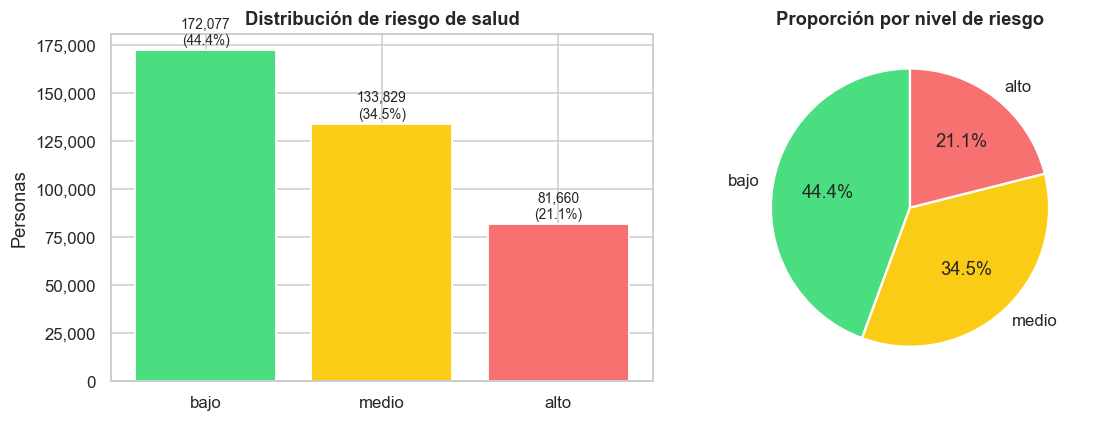

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
colors = ['#4ade80', '#facc15', '#f87171']

axes[0].bar(conteo.index, conteo.values, color=colors, edgecolor='white', linewidth=1.2)
for i, (v, p) in enumerate(zip(conteo.values, pct.values)):
    axes[0].text(i, v + 3000, f'{v:,}\n({p:.1f}%)', ha='center', fontsize=9)
axes[0].set_title('Distribución de riesgo de salud', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Personas')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

axes[1].pie(conteo.values, labels=conteo.index, autopct='%1.1f%%',
            colors=colors, startangle=90,
            wedgeprops=dict(edgecolor='white', linewidth=1.5))
axes[1].set_title('Proporción por nivel de riesgo', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

## 4. Demografía — Edad y Sexo

In [10]:
print("Grupos de edad únicos:", sorted(df['grupo_edad'].dropna().unique()))
print()
print(df['sexo'].value_counts())

Grupos de edad únicos: ['18-24', '25-34', '35-44', '45-54', '55-64', '65+']

sexo
femenino     207544
masculino    180022
Name: count, dtype: int64


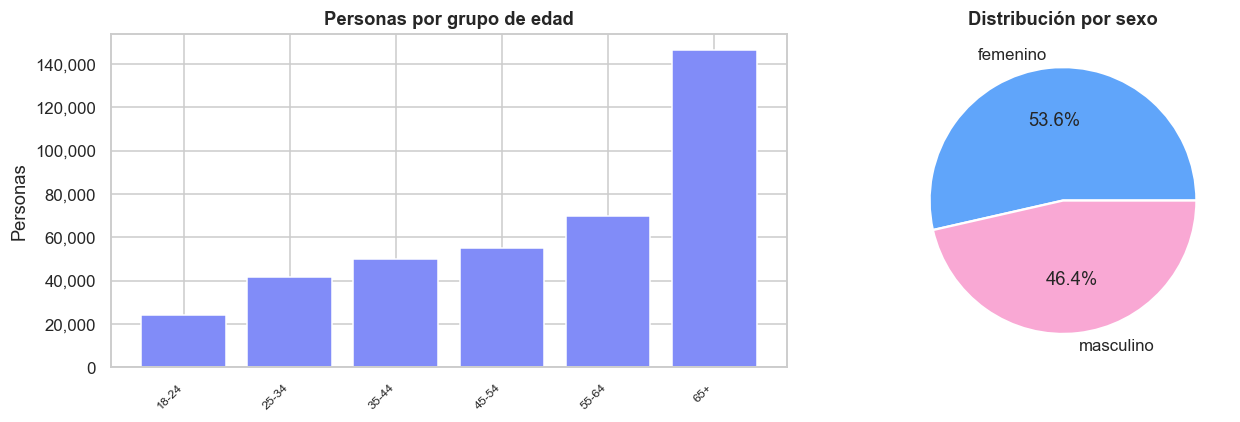

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

age_order  = sorted(df['grupo_edad'].dropna().unique())
age_counts = df['grupo_edad'].value_counts().reindex(age_order)
axes[0].bar(range(len(age_order)), age_counts.values, color='#818cf8', edgecolor='white')
axes[0].set_xticks(range(len(age_order)))
axes[0].set_xticklabels([str(a) for a in age_order], rotation=45, ha='right', fontsize=8)
axes[0].set_title('Personas por grupo de edad', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Personas')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

sex_counts = df['sexo'].value_counts()
axes[1].pie(sex_counts.values, labels=sex_counts.index, autopct='%1.1f%%',
            colors=['#60a5fa', '#f9a8d4'],
            wedgeprops=dict(edgecolor='white', linewidth=1.5))
axes[1].set_title('Distribución por sexo', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

## 5. Medidas físicas — Peso, Altura, IMC

In [12]:
df_f[['weight_kg', 'height_cm', 'bmi_computed']].describe().round(2)

,weight_kg,height_cm,bmi_computed
count,432733.00,432733.00,432733.00
mean,82.69,170.24,28.38
std,20.50,10.47,6.29
min,22.68,91.00,3.90
25%,68.04,163.00,24.40
50%,80.29,170.00,27.30
75%,92.08,178.00,31.10
max,284.00,241.00,147.50


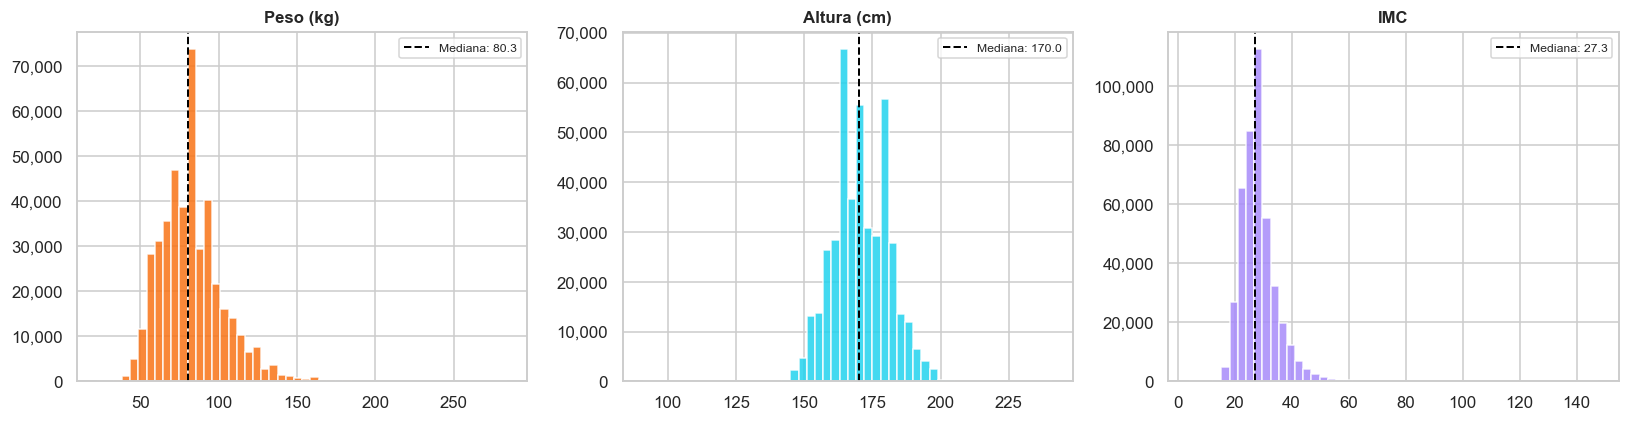

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, col, label, color in [
    (axes[0], 'weight_kg',    'Peso (kg)',   '#f97316'),
    (axes[1], 'height_cm',   'Altura (cm)',  '#22d3ee'),
    (axes[2], 'bmi_computed', 'IMC',         '#a78bfa'),
]:
    data = df_f[col].dropna()
    ax.hist(data, bins=50, color=color, edgecolor='white', alpha=0.85)
    ax.axvline(data.median(), color='black', linestyle='--', linewidth=1.3,
               label=f'Mediana: {data.median():.1f}')
    ax.set_title(label, fontsize=11, fontweight='bold')
    ax.legend(fontsize=8)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.tight_layout()
plt.show()

## 6. Condiciones crónicas

Porcentaje de encuestados que reportó cada enfermedad.

In [14]:
condiciones = {
    'tiene_diabetes':              'Diabetes',
    'tiene_cardiopatia_coronaria': 'Cardiopatía coronaria',
    'tiene_depresion':             'Depresión',
    'tiene_cancer_piel':           'Cáncer de piel',
    'tiene_otro_cancer':           'Otro cáncer',
    'tiene_artritis':              'Artritis',
    'tiene_asma':                  'Asma',
}

rows = []
for col, nombre in condiciones.items():
    if col in df.columns:
        n   = (df[col] == 'si').sum()
        pct = (df[col] == 'si').mean() * 100
        rows.append({'Condición': nombre, 'N personas': f'{n:,}', '% del total': round(pct, 1)})

pd.DataFrame(rows).sort_values('% del total', ascending=False).reset_index(drop=True)

,Condición,N personas,% del total
0,Artritis,"135,157",34.9
1,Depresión,"87,377",22.5
2,Asma,"63,247",16.3
3,Diabetes,"58,139",15.0
4,Otro cáncer,"49,000",12.6
5,Cáncer de piel,"35,317",9.1
6,Cardiopatía coronaria,"23,122",6.0


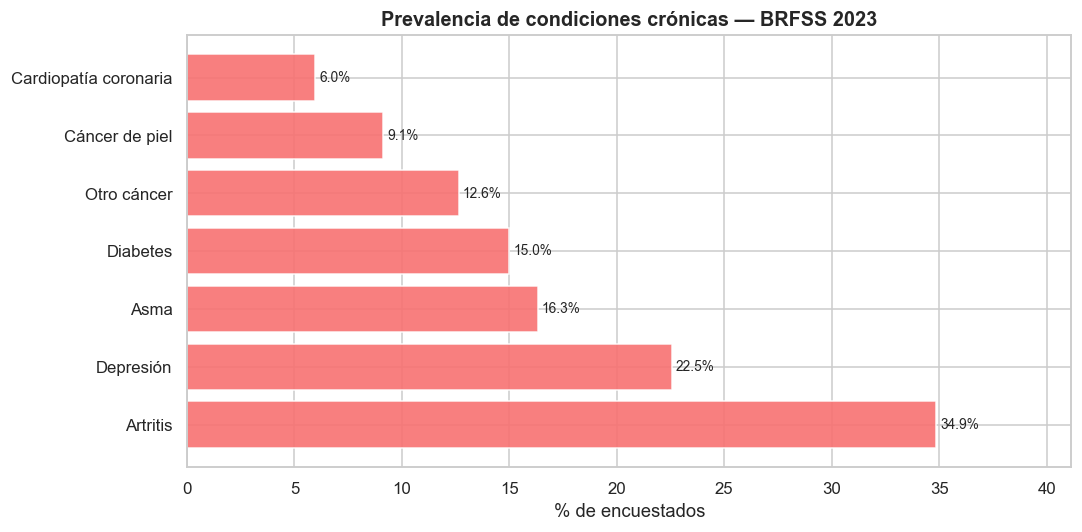

In [15]:
data_plot = sorted(
    [(nombre, (df[col] == 'si').mean() * 100)
     for col, nombre in condiciones.items() if col in df.columns],
    key=lambda x: x[1], reverse=True
)
nombres, porcentajes = zip(*data_plot)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(nombres, porcentajes, color='#f87171', edgecolor='white', alpha=0.9)
for bar, pct in zip(bars, porcentajes):
    ax.text(pct + 0.2, bar.get_y() + bar.get_height() / 2,
            f'{pct:.1f}%', va='center', fontsize=9)
ax.set_xlim(0, max(porcentajes) * 1.18)
ax.set_xlabel('% de encuestados')
ax.set_title('Prevalencia de condiciones crónicas — BRFSS 2023', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 7. Número de condiciones acumuladas

**Predictor #1 del modelo CareBridge** (importancia SHAP = 0.321).

In [16]:
df_f['condition_count'].value_counts().sort_index().to_frame('personas')

,personas
condition_count,
0.0,131540
1.0,127393
2.0,95903
3.0,50791
4.0,19859
5.0,5776
6.0,1298
7.0,173


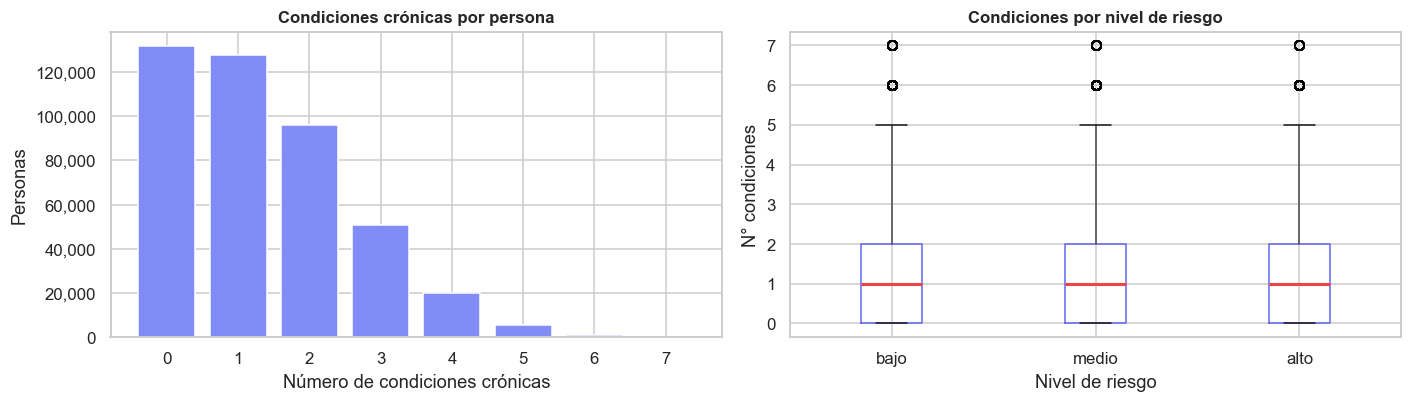

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

cc = df_f['condition_count'].value_counts().sort_index()
axes[0].bar(cc.index, cc.values, color='#818cf8', edgecolor='white')
axes[0].set_xlabel('Número de condiciones crónicas')
axes[0].set_ylabel('Personas')
axes[0].set_title('Condiciones crónicas por persona', fontsize=11, fontweight='bold')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

df_merged = pd.concat([df_f[['condition_count']], df[['riesgo_salud_label']]], axis=1)
orden = ['bajo', 'medio', 'alto']
df_merged['riesgo_salud_label'] = pd.Categorical(
    df_merged['riesgo_salud_label'], categories=orden, ordered=True)
df_merged.boxplot(column='condition_count', by='riesgo_salud_label', ax=axes[1],
                  boxprops=dict(color='#6366f1'),
                  medianprops=dict(color='#ef4444', linewidth=2))
axes[1].set_title('Condiciones por nivel de riesgo', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Nivel de riesgo')
axes[1].set_ylabel('N° condiciones')
plt.suptitle('')
plt.tight_layout()
plt.show()

## 8. Hábitos de vida — Ejercicio y Alcohol

In [18]:
print("Ejercicio último mes:")
print(df['ejercicio_ultimo_mes'].value_counts())
print()
print("Consumo de alcohol:")
print(df['consumo_alcohol'].value_counts())

Ejercicio último mes:
ejercicio_ultimo_mes
si    285240
no    102326
Name: count, dtype: int64

Consumo de alcohol:
consumo_alcohol
si    212335
no    175231
Name: count, dtype: int64


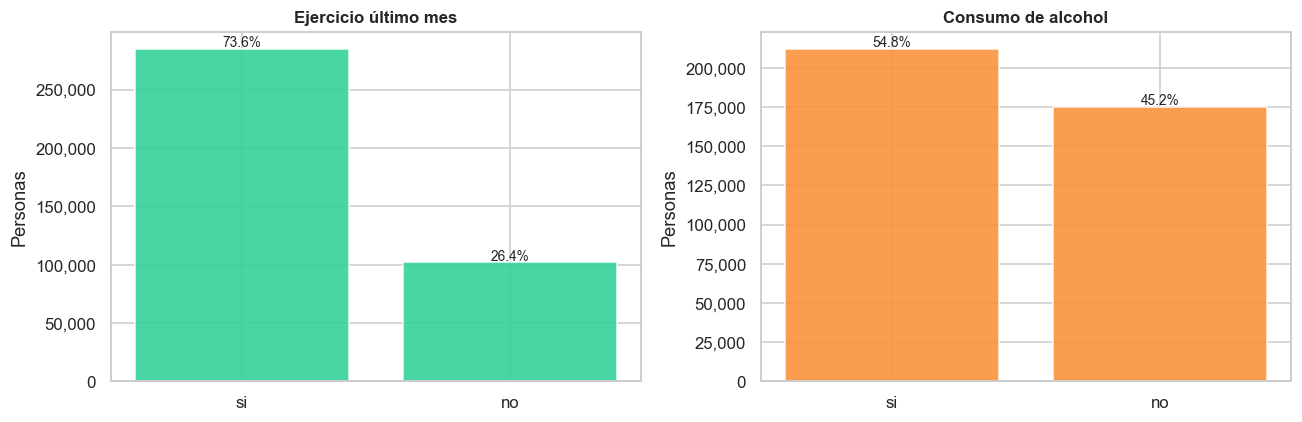

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, col, label, color in [
    (axes[0], 'ejercicio_ultimo_mes', 'Ejercicio último mes', '#34d399'),
    (axes[1], 'consumo_alcohol',       'Consumo de alcohol',   '#fb923c'),
]:
    vc = df[col].value_counts()
    ax.bar(vc.index, vc.values, color=color, edgecolor='white', alpha=0.9)
    for i, v in enumerate(vc.values):
        ax.text(i, v + 1500, f'{v / len(df) * 100:.1f}%', ha='center', fontsize=9)
    ax.set_title(label, fontsize=11, fontweight='bold')
    ax.set_ylabel('Personas')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.tight_layout()
plt.show()

## 9. Días de mala salud al mes

Días en el último mes con mala salud mental o física.  
*(El valor 88 significa "no aplica", lo filtramos.)*

In [20]:
mental_v = df_f['poor_mental_health_days'].dropna()
mental_v = mental_v[mental_v <= 30]

fisico_v = df_f['poor_physical_health_days'].dropna()
fisico_v = fisico_v[fisico_v <= 30]

print(f"Salud mental  — mediana: {mental_v.median():.0f} días  |  media: {mental_v.mean():.1f} días")
print(f"Salud física  — mediana: {fisico_v.median():.0f} días  |  media: {fisico_v.mean():.1f} días")

Salud mental  — mediana: 7 días  |  media: 11.0 días
Salud física  — mediana: 6 días  |  media: 11.4 días


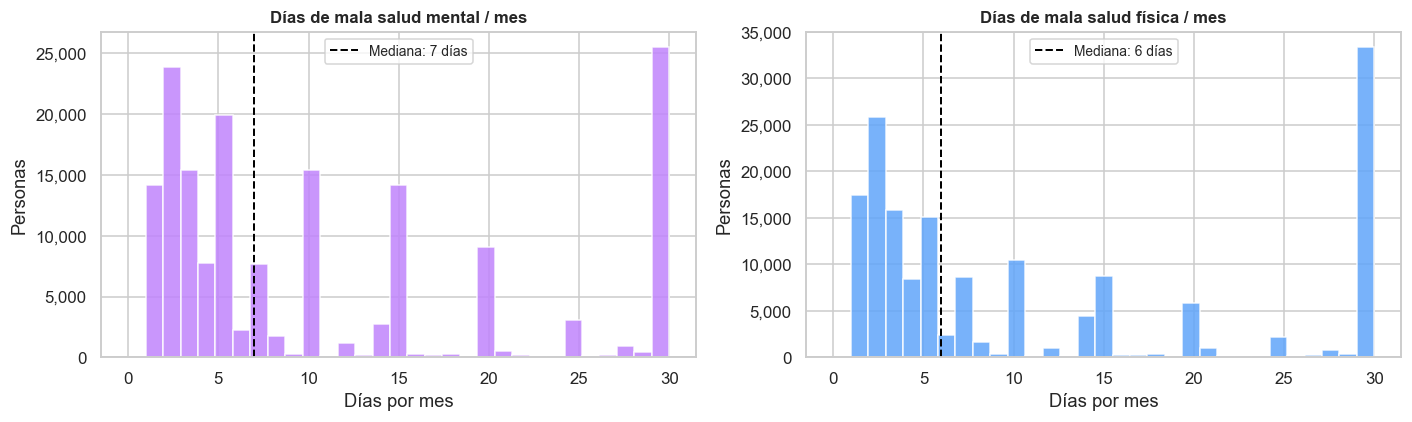

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, data, label, color in [
    (axes[0], mental_v, 'Días de mala salud mental / mes', '#c084fc'),
    (axes[1], fisico_v, 'Días de mala salud física / mes', '#60a5fa'),
]:
    ax.hist(data, bins=31, range=(0, 30), color=color, edgecolor='white', alpha=0.85)
    ax.axvline(data.median(), color='black', linestyle='--', linewidth=1.3,
               label=f'Mediana: {data.median():.0f} días')
    ax.set_title(label, fontsize=11, fontweight='bold')
    ax.set_xlabel('Días por mes')
    ax.set_ylabel('Personas')
    ax.legend(fontsize=9)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.tight_layout()
plt.show()

## 10. Mapa de correlaciones

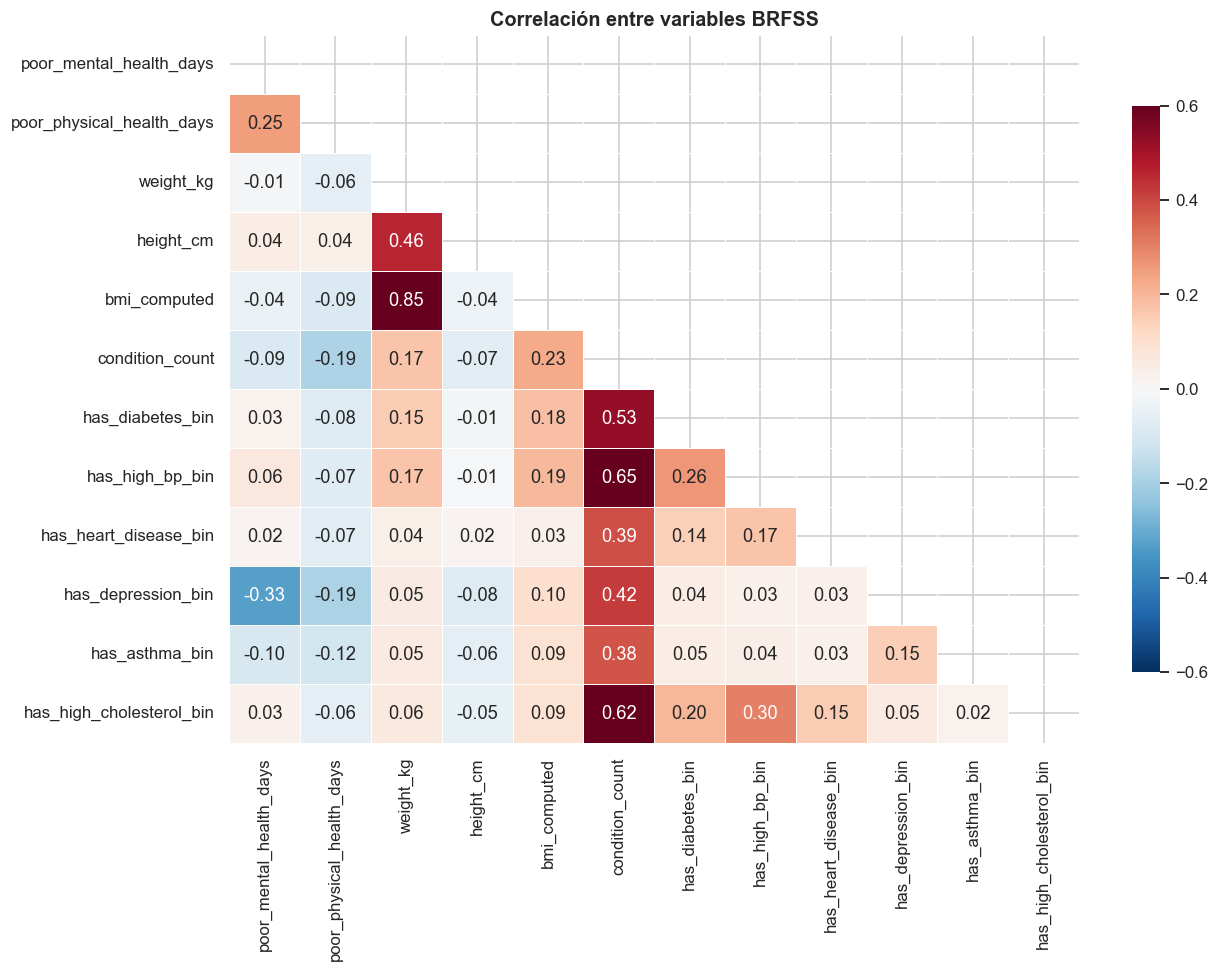

In [22]:
cols_corr = [
    'poor_mental_health_days', 'poor_physical_health_days',
    'weight_kg', 'height_cm', 'bmi_computed', 'condition_count',
    'has_diabetes_bin', 'has_high_bp_bin', 'has_heart_disease_bin',
    'has_depression_bin', 'has_asthma_bin', 'has_high_cholesterol_bin',
]
cols_ok = [c for c in cols_corr if c in df_f.columns]
corr = df_f[cols_ok].corr()

fig, ax = plt.subplots(figsize=(12, 9))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-0.6, vmax=0.6,
            linewidths=0.5, ax=ax, cbar_kws={'shrink': 0.8})
ax.set_title('Correlación entre variables BRFSS', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 11. Riesgo de salud por grupo de edad

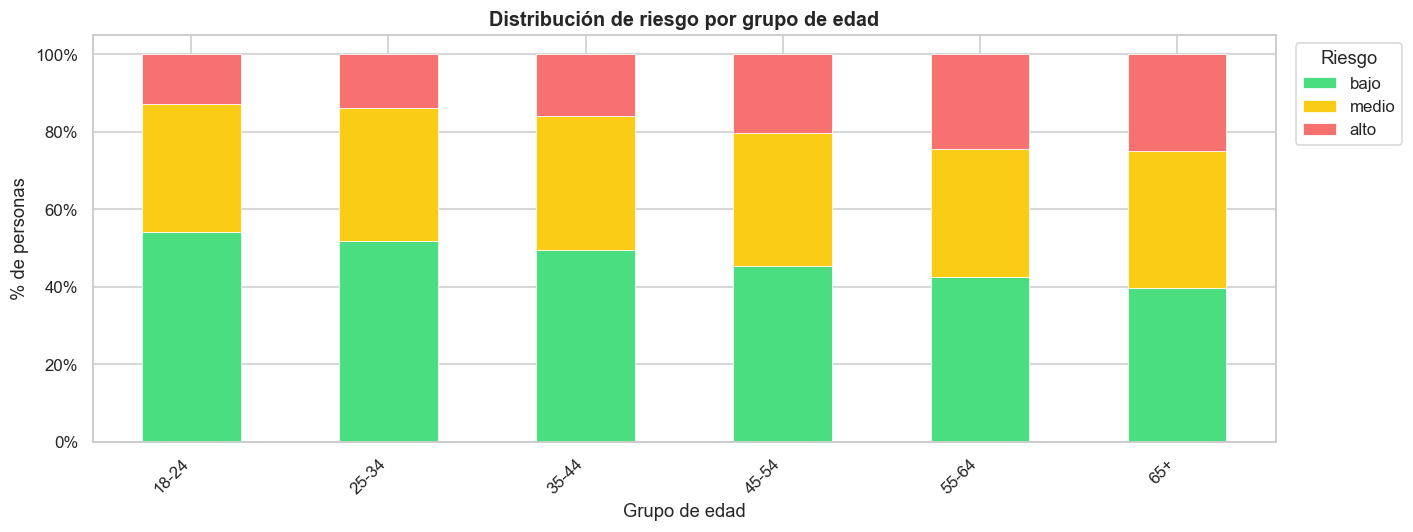

In [23]:
pivot = (df.groupby(['grupo_edad', 'riesgo_salud_label'])
           .size()
           .unstack(fill_value=0)
           .apply(lambda r: r / r.sum() * 100, axis=1))

for col in ['bajo', 'medio', 'alto']:
    if col not in pivot.columns:
        pivot[col] = 0
pivot = pivot[['bajo', 'medio', 'alto']]

fig, ax = plt.subplots(figsize=(13, 5))
pivot.plot(kind='bar', stacked=True, ax=ax,
           color=['#4ade80', '#facc15', '#f87171'],
           edgecolor='white', linewidth=0.5)
ax.set_xlabel('Grupo de edad')
ax.set_ylabel('% de personas')
ax.set_title('Distribución de riesgo por grupo de edad', fontsize=13, fontweight='bold')
ax.legend(title='Riesgo', bbox_to_anchor=(1.01, 1), loc='upper left')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}%'))
plt.tight_layout()
plt.show()

## 12. Tabla resumen por nivel de riesgo

In [25]:
df_merged2 = pd.concat([
    df_f[['weight_kg', 'height_cm', 'bmi_computed',
          'poor_mental_health_days', 'poor_physical_health_days', 'condition_count']],
    df[['riesgo_salud_label']]
], axis=1)

resumen = df_merged2.groupby('riesgo_salud_label').agg(
    n=('condition_count', 'count'),
    peso_mediana=('weight_kg', 'median'),
    imc_mediana=('bmi_computed', 'median'),
    dias_mental=('poor_mental_health_days', 'median'),
    dias_fisico=('poor_physical_health_days', 'median'),
    condiciones_media=('condition_count', 'mean'),
).round(2).reindex(['bajo', 'medio', 'alto'])

resumen.index.name = 'Riesgo'
resumen.columns = ['N', 'Peso med. (kg)', 'IMC med.',
                   'Días mental med.', 'Días físico med.', 'Condiciones media']
resumen

,N,Peso med. (kg),IMC med.,Días mental med.,Días físico med.,Condiciones media
Riesgo,,,,,,
bajo,172077,80.29,27.3,88.0,88.0,1.35
medio,133829,80.29,27.3,88.0,88.0,1.36
alto,81660,80.29,27.3,88.0,88.0,1.36
